In [1]:
from google.colab import drive
# Mount Google Drive to access dataset and save models
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os, random, math, time
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [3]:
# Configuration class for paths, hyperparameters, and device settings
class Config:
    ROOT = "/content/drive/MyDrive/AI Based Oil Spill Detection"
    DATASET_PATH = f"{ROOT}/dataset"
    SAVE_MODEL_PATH = f"{ROOT}/best_unet_oilspill.pth"
    PRED_SAVE_DIR = f"{ROOT}/predictions"
    IMAGE_SIZE = (256, 256)
    BATCH_SIZE = 8
    LEARNING_RATE = 1e-4
    EPOCHS = 40
    NUM_CLASSES = 2  # background + spill
    NUM_WORKERS = 2
    SEED = 42
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # Will try to read from label_colors.txt; fallback below
    SPILL_COLOR = np.array([255, 0, 124], dtype=np.uint8)

cfg = Config()
os.makedirs(cfg.PRED_SAVE_DIR, exist_ok=True)

In [4]:
# Reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seed(cfg.SEED)

In [5]:
# Load class color info (from label_colors.txt)
colors_path = os.path.join(cfg.DATASET_PATH, "label_colors.txt")
if os.path.exists(colors_path):
    try:
        with open(colors_path, "r") as f:
            lines = [l.strip() for l in f if l.strip()]
        if len(lines) >= 2:
            # pick second non-empty line (class 1)
            parts = lines[1].replace(",", " ").split()
            # take first three tokens that are ints
            rgb = []
            for p in parts:
                try:
                    rgb.append(int(p))
                    if len(rgb) == 3: break
                except:
                    continue
            if len(rgb) == 3:
                cfg.SPILL_COLOR = np.array(rgb, dtype=np.uint8)
                print(f"Using spill color from label_colors.txt: {cfg.SPILL_COLOR.tolist()}")
            else:
                print("label_colors.txt found but couldn't parse RGB ints; using default color.")
    except Exception as e:
        print("Could not parse label_colors.txt; using default spill color.", str(e))
else:
    print("label_colors.txt not found; using default spill color.")

Using spill color from label_colors.txt: [255, 0, 124]


In [6]:
# Helper to find matching mask for an image
def find_matching_mask(image_path, masks_dir):
    stem = os.path.splitext(os.path.basename(image_path))[0]
    # exact name match with common extensions
    for ext in (".png", ".jpg", ".jpeg"):
        candidate = os.path.join(masks_dir, stem + ext)
        if os.path.exists(candidate):
            return candidate
    # fallback: fuzzy search
    if os.path.isdir(masks_dir):
        for f in os.listdir(masks_dir):
            if stem in f:
                return os.path.join(masks_dir, f)
    return None

In [7]:
# Custom Dataset for oil spill segmentation
class OilSpillSegDataset(Dataset):
    def __init__(self, images_dir, masks_dir, transforms=None, spill_color_rgb=None):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.transforms = transforms
        self.spill_color = (spill_color_rgb if spill_color_rgb is not None
                            else cfg.SPILL_COLOR)
        self.images = sorted([f for f in os.listdir(images_dir)
                              if f.lower().endswith((".png", ".jpg", ".jpeg"))])
        if len(self.images) == 0:
            raise RuntimeError(f"No images found in {images_dir}")

    def __len__(self): return len(self.images)

    def __getitem__(self, idx):
        # Load image
        img_name = self.images[idx]
        img_path = os.path.join(self.images_dir, img_name)

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Load mask (or fallback to empty mask)
        mask_path = find_matching_mask(img_path, self.masks_dir)
        if mask_path:
            mask_rgb = cv2.imread(mask_path)
            mask_rgb = cv2.cvtColor(mask_rgb, cv2.COLOR_BGR2RGB)
        else:
            # fallback if no mask — all background
            mask_rgb = np.zeros_like(image)

        # Convert RGB mask to binary mask (0=background, 1=spill)
        spill_color = self.spill_color.reshape(1,1,3)
        mask_binary = np.all(mask_rgb == spill_color, axis=-1).astype(np.uint8)

        # Apply augmentations
        if self.transforms:
            augmented = self.transforms(image=image, mask=mask_binary)
            image = augmented["image"]
            mask_binary = augmented["mask"]
        else:
            t = A.Compose([
                A.Resize(cfg.IMAGE_SIZE[0], cfg.IMAGE_SIZE[1]),
                A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
                ToTensorV2()
            ])
            out = t(image=image, mask=mask_binary)
            image = out["image"]
            mask_binary = out["mask"]

        # Convert mask to tensor
        if isinstance(mask_binary, np.ndarray):
            mask_tensor = torch.from_numpy(mask_binary).long()
        else:
            mask_tensor = mask_binary.long()

        return image.float(), mask_tensor, img_name

In [8]:
# Data augmentations (train vs validation)
def get_transforms(phase="train"):
    if phase == "train":
        return A.Compose([
            A.Resize(cfg.IMAGE_SIZE[0], cfg.IMAGE_SIZE[1]),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.2),
            A.RandomRotate90(p=0.5),
            # Replace ShiftScaleRotate with Affine (warning-free)
            A.Affine(scale=(0.9, 1.1), translate_percent=(0.0, 0.08),
                     rotate=(-20, 20), shear=(-8, 8), p=0.7),
            A.RandomBrightnessContrast(p=0.5),
            A.GaussNoise(p=0.2),
            A.Normalize(mean=(0.485,0.456,0.406),
                        std=(0.229,0.224,0.225)),
            ToTensorV2()
        ])
    else:
        return A.Compose([
            A.Resize(cfg.IMAGE_SIZE[0], cfg.IMAGE_SIZE[1]),
            A.Normalize(mean=(0.485,0.456,0.406),
                        std=(0.229,0.224,0.225)),
            ToTensorV2()
        ])

In [9]:
# U-Net architecture (with DoubleConv blocks)
class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.double_conv(x)

class UNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=2, features=[64,128,256,512]):
        super().__init__()
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.pool = nn.MaxPool2d(2)

        # Encoder
        ch = in_ch
        for feat in features:
            self.downs.append(DoubleConv(ch, feat))
            ch = feat

        # Bottleneck
        self.bottleneck = DoubleConv(features[-1], features[-1]*2)

        # Decoder
        for feat in reversed(features):
            self.ups.append(nn.ConvTranspose2d(feat*2, feat, 2, stride=2))
            self.ups.append(DoubleConv(feat*2, feat))

        self.final_conv = nn.Conv2d(features[0], out_ch, 1)

    def forward(self, x):
        skips = []
        for down in self.downs:
            x = down(x)
            skips.append(x)
            x = self.pool(x)
        x = self.bottleneck(x)
        skips = skips[::-1]
        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip = skips[idx//2]
            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[2:], mode="bilinear", align_corners=False)
            x = torch.cat([skip, x], dim=1)
            x = self.ups[idx+1](x)
        return self.final_conv(x)

In [10]:
# Loss functions (Dice + CE hybrid)
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__(); self.smooth = smooth
    def forward(self, logits, targets):
        # logits: (B,C,H,W), targets: (B,H,W)
        probs = torch.softmax(logits, dim=1)
        onehot = torch.zeros_like(probs)
        onehot.scatter_(1, targets.unsqueeze(1), 1)  # (B,C,H,W)
        inter = (probs * onehot).sum(dim=(0,2,3))
        union = probs.sum(dim=(0,2,3)) + onehot.sum(dim=(0,2,3))
        dice = (2*inter + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()

class CombinedLoss(nn.Module):
    def __init__(self, alpha=0.5):
        super().__init__()
        self.ce = nn.CrossEntropyLoss()
        self.dice = DiceLoss()
        self.alpha = alpha
    def forward(self, logits, targets):
        return self.alpha * self.ce(logits, targets) + (1-self.alpha) * self.dice(logits, targets)

# Metric calculation (Acc, IoU, Dice)
@torch.no_grad()
def calc_metrics(preds, targets, num_classes=2):
    # preds, targets: (B,H,W)
    p = preds.cpu().numpy().astype(np.int32)
    t = targets.cpu().numpy().astype(np.int32)
    acc = (p == t).mean()
    ious = []
    dices = []
    for c in range(num_classes):
        pc = (p == c)
        tc = (t == c)
        inter = np.logical_and(pc, tc).sum()
        union = np.logical_or(pc, tc).sum()
        iou = inter / union if union > 0 else 1.0
        ious.append(iou)
        dice = (2*inter) / (pc.sum() + tc.sum() + 1e-6) if (pc.sum()+tc.sum())>0 else 1.0
        dices.append(dice)
    return float(acc), float(np.mean(ious)), ious, float(np.mean(dices))

In [11]:
# DataLoaders for train/val/test
def make_loaders():
    # Adjust settings based on device
    use_cuda = torch.cuda.is_available()
    num_workers = 2 if use_cuda else 0
    pin_memory = True if use_cuda else False

    train_ds = OilSpillSegDataset(
        os.path.join(cfg.DATASET_PATH, "train", "images"),
        os.path.join(cfg.DATASET_PATH, "train", "masks"),
        transforms=get_transforms("train"),
        spill_color_rgb=cfg.SPILL_COLOR
    )
    val_ds = OilSpillSegDataset(
        os.path.join(cfg.DATASET_PATH, "val", "images"),
        os.path.join(cfg.DATASET_PATH, "val", "masks"),
        transforms=get_transforms("val"),
        spill_color_rgb=cfg.SPILL_COLOR
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=cfg.BATCH_SIZE,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=use_cuda  # only keep workers alive if CUDA
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=cfg.BATCH_SIZE,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=use_cuda
    )
    return train_loader, val_loader

# Early stopping utility
class EarlyStopper:
    def __init__(self, patience=6, mode="max"):
        self.patience = patience
        self.mode = mode
        self.best = -np.inf if mode == "max" else np.inf
        self.num_bad = 0
    def step(self, value):
        improved = value > self.best if self.mode == "max" else value < self.best
        if improved:
            self.best = value
            self.num_bad = 0
            return True
        else:
            self.num_bad += 1
            return False
    def should_stop(self):
        return self.num_bad >= self.patience

# Training and validation loops
def train_one_epoch(model, loader, criterion, optim, scaler, device):
    model.train()
    tot_loss=tot_acc=tot_miou=tot_mdice=0.0
    for imgs, masks, _ in tqdm(loader, desc="Train"):
        imgs, masks = imgs.to(device, non_blocking=True), masks.to(device, non_blocking=True)
        optim.zero_grad(set_to_none=True)
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=(device.type=="cuda")):
            outs = model(imgs)
            loss = criterion(outs, masks)
        scaler.scale(loss).backward()
        scaler.step(optim)
        scaler.update()
        preds = torch.argmax(outs, dim=1)
        acc, miou, _, mdice = calc_metrics(preds, masks, cfg.NUM_CLASSES)
        tot_loss += loss.item(); tot_acc += acc; tot_miou += miou; tot_mdice += mdice
    n = len(loader)
    return tot_loss/n, tot_acc/n, tot_miou/n, tot_mdice/n

@torch.no_grad()
def val_one_epoch(model, loader, criterion, device):
    model.eval()
    tot_loss=tot_acc=tot_miou=tot_mdice=0.0
    for imgs, masks, _ in tqdm(loader, desc="Val"):
        imgs, masks = imgs.to(device, non_blocking=True), masks.to(device, non_blocking=True)
        outs = model(imgs)
        loss = criterion(outs, masks)
        preds = torch.argmax(outs, dim=1)
        acc, miou, _, mdice = calc_metrics(preds, masks, cfg.NUM_CLASSES)
        tot_loss += loss.item(); tot_acc += acc; tot_miou += miou; tot_mdice += mdice
    n = len(loader)
    return tot_loss/n, tot_acc/n, tot_miou/n, tot_mdice/n

# Main training pipeline
def main_train():
    train_loader, val_loader = make_loaders()
    model = UNet(in_ch=3, out_ch=cfg.NUM_CLASSES).to(cfg.DEVICE)
    criterion = CombinedLoss(alpha=0.5)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.LEARNING_RATE, weight_decay=1e-4)

    # Remove verbose (not supported in older PyTorch versions)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", patience=3, factor=0.5
    )

    scaler = torch.cuda.amp.GradScaler(enabled=(cfg.DEVICE.type == "cuda"))
    early = EarlyStopper(patience=6, mode="max")

    best_iou = 0.0
    for e in range(cfg.EPOCHS):
        print(f"\nEpoch {e+1}/{cfg.EPOCHS}")

        tr_loss, tr_acc, tr_iou, tr_dice = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, cfg.DEVICE
        )
        val_loss, val_acc, val_iou, val_dice = val_one_epoch(
            model, val_loader, criterion, cfg.DEVICE
        )

        print(f"Train: Loss {tr_loss:.4f}  Acc {tr_acc:.4f}  mIoU {tr_iou:.4f}  mDice {tr_dice:.4f}")
        print(f"Val  : Loss {val_loss:.4f}  Acc {val_acc:.4f}  mIoU {val_iou:.4f}  mDice {val_dice:.4f}")

        # Step scheduler (ReduceLROnPlateau expects a metric value, not loss)
        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_iou)
        new_lr = optimizer.param_groups[0]['lr']
        if new_lr != old_lr:
            print(f"Learning rate reduced: {old_lr:.6f} → {new_lr:.6f}")

        # Save best model
        if val_iou > best_iou:
            best_iou = val_iou
            torch.save(model.state_dict(), cfg.SAVE_MODEL_PATH)
            print(f"✅ Saved best model to {cfg.SAVE_MODEL_PATH} (mIoU={best_iou:.4f})")

        # Early stopping check
        if not early.step(val_iou):
            if early.should_stop():
                print("Early stopping triggered.")
                break

    return model


model = main_train()

/tmp/ipython-input-1800357835.py:100: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(cfg.DEVICE.type == "cuda"))



Epoch 1/40


Val: 100%|██████████| 26/26 [01:59<00:00,  4.61s/it]


Train: Loss 0.4040  Acc 0.7803  mIoU 0.6116  mDice 0.7459
Val  : Loss 0.3640  Acc 0.8148  mIoU 0.6425  mDice 0.7490
✅ Saved best model to /content/drive/MyDrive/AI Based Oil Spill Detection/best_unet_oilspill.pth (mIoU=0.6425)

Epoch 2/40


Val: 100%|██████████| 26/26 [00:21<00:00,  1.22it/s]


...

Train: Loss 0.2140  Acc 0.8880  mIoU 0.7721  mDice 0.8660
Val  : Loss 0.2142  Acc 0.9071  mIoU 0.7855  mDice 0.8558

Epoch 39/40


Val: 100%|██████████| 26/26 [00:19<00:00,  1.36it/s]


Train: Loss 0.2097  Acc 0.8913  mIoU 0.7806  mDice 0.8714
Val  : Loss 0.1817  Acc 0.9326  mIoU 0.8254  mDice 0.8870
✅ Saved best model to /content/drive/MyDrive/AI Based Oil Spill Detection/best_unet_oilspill.pth (mIoU=0.8254)

Epoch 40/40


Val: 100%|██████████| 26/26 [00:21<00:00,  1.22it/s]

Train: Loss 0.2111  Acc 0.8911  mIoU 0.7767  mDice 0.8687
Val  : Loss 0.1905  Acc 0.9288  mIoU 0.8163  mDice 0.8820


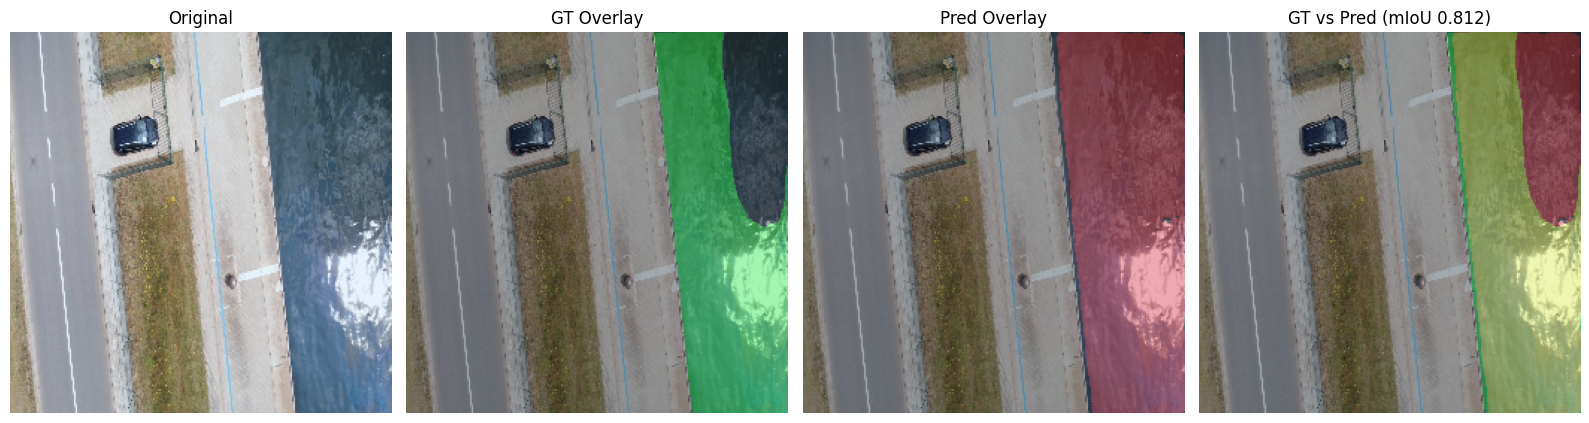

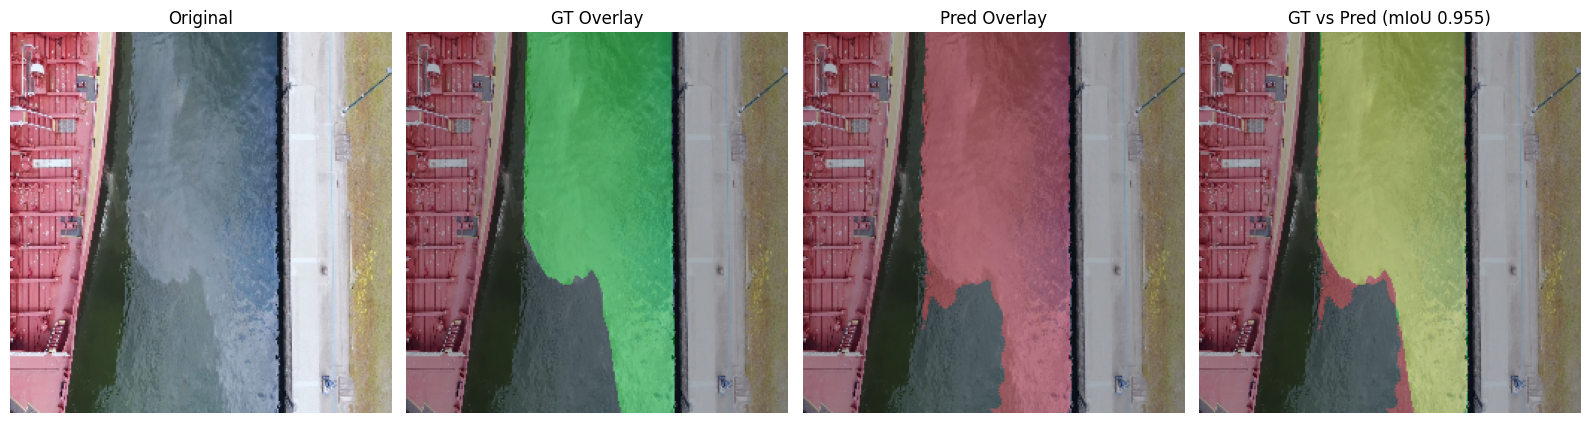

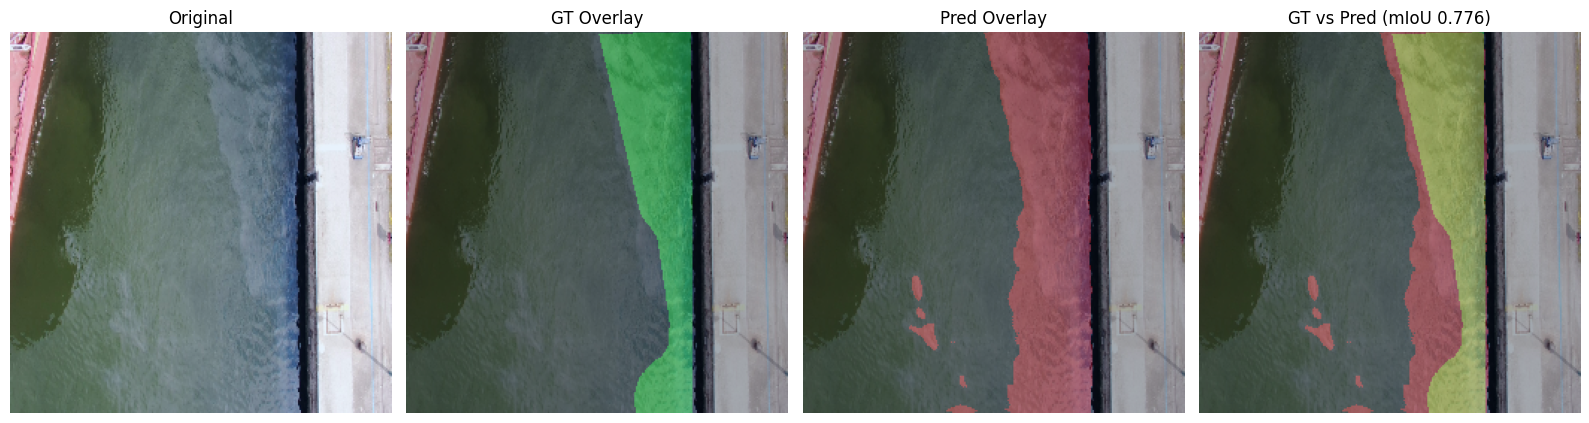

In [15]:
@torch.no_grad()
def visualize_predictions_with_overlay(model, loader, device, num_samples=3, save_dir=None):
    model.eval()
    imgs, masks, names = next(iter(loader))
    imgs, masks = imgs.to(device), masks.to(device)
    outs = model(imgs)
    preds = torch.argmax(outs, dim=1)

    for i in range(min(num_samples, imgs.size(0))):
        img = imgs[i].cpu().permute(1,2,0).numpy()
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        mask = masks[i].cpu().numpy()
        pred = preds[i].cpu().numpy()

        # Overlays
        def make_overlay(img, binary, color):
            overlay = np.zeros_like(img)
            overlay[binary==1] = color
            return 0.7*img + 0.3*overlay

        gt_overlay   = make_overlay(img, mask, np.array([0,1,0]))   # green
        pr_overlay   = make_overlay(img, pred, np.array([1,0,0]))   # red
        both = np.zeros_like(img)
        both[mask==1] = [0,1,0]
        both[pred==1] = [1,0,0]
        both[(mask==1) & (pred==1)] = [1,1,0]  # yellow overlap
        combo_overlay = 0.7*img + 0.3*both

        # Compute per-sample metrics
        acc, miou, ious, mdice = calc_metrics(torch.from_numpy(pred), torch.from_numpy(mask), cfg.NUM_CLASSES)

        plt.figure(figsize=(16,5))
        plt.subplot(1,4,1); plt.imshow(img); plt.title("Original"); plt.axis("off")
        plt.subplot(1,4,2); plt.imshow(gt_overlay); plt.title("GT Overlay"); plt.axis("off")
        plt.subplot(1,4,3); plt.imshow(pr_overlay); plt.title("Pred Overlay"); plt.axis("off")
        plt.subplot(1,4,4); plt.imshow(combo_overlay); plt.title(f"GT vs Pred (mIoU {miou:.3f})"); plt.axis("off")
        plt.tight_layout(); plt.show()

        if save_dir:
            out_path = os.path.join(save_dir, f"vis_{names[i]}")
            cv2.imwrite(out_path, cv2.cvtColor((combo_overlay*255).astype(np.uint8), cv2.COLOR_RGB2BGR))

# Load best model for eval/vis
best_model = UNet(in_ch=3, out_ch=cfg.NUM_CLASSES).to(cfg.DEVICE)
best_model.load_state_dict(torch.load(cfg.SAVE_MODEL_PATH, map_location=cfg.DEVICE))
best_model.eval()

# Visualize a few from validation
val_loader = DataLoader(
    OilSpillSegDataset(os.path.join(cfg.DATASET_PATH,"val","images"),
                       os.path.join(cfg.DATASET_PATH,"val","masks"),
                       transforms=get_transforms("val"),
                       spill_color_rgb=cfg.SPILL_COLOR),
    batch_size=cfg.BATCH_SIZE, shuffle=True, num_workers=cfg.NUM_WORKERS, pin_memory=True
)
visualize_predictions_with_overlay(best_model, val_loader, cfg.DEVICE, num_samples=3)

In [16]:
@torch.no_grad()
def evaluate_on_loader(model, loader, device, save_preds=False, save_dir=None, tta=False):
    model.eval()
    tot_acc=tot_miou=tot_mdice=0.0; n_batches=0
    for imgs, masks, names in tqdm(loader, desc="Test"):
        imgs = imgs.to(device)
        masks = masks.to(device)

        if not tta:
            outs = model(imgs)
        else:
            # simple TTA: identity + hflip
            outs = model(imgs)
            outs_flip = model(torch.flip(imgs, dims=[3]))
            outs_flip = torch.flip(outs_flip, dims=[3])
            outs = (outs + outs_flip) / 2.0

        preds = torch.argmax(outs, dim=1)
        acc, miou, _, mdice = calc_metrics(preds, masks, cfg.NUM_CLASSES)
        tot_acc+=acc; tot_miou+=miou; tot_mdice+=mdice; n_batches+=1

        if save_preds and save_dir:
            for i in range(preds.size(0)):
                pred = preds[i].cpu().numpy().astype(np.uint8)*255
                cv2.imwrite(os.path.join(save_dir, f"pred_{names[i]}"), pred)

    return tot_acc/n_batches, tot_miou/n_batches, tot_mdice/n_batches

test_loader = DataLoader(
    OilSpillSegDataset(os.path.join(cfg.DATASET_PATH,"test","images"),
                       os.path.join(cfg.DATASET_PATH,"test","masks"),
                       transforms=get_transforms("val"),
                       spill_color_rgb=cfg.SPILL_COLOR),
    batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=cfg.NUM_WORKERS, pin_memory=True
)

acc, miou, mdice = evaluate_on_loader(best_model, test_loader, cfg.DEVICE, save_preds=True, save_dir=cfg.PRED_SAVE_DIR, tta=True)
print(f"\nTest set — Acc: {acc:.4f}  mIoU: {miou:.4f}  mDice: {mdice:.4f}")
print(f"Predictions saved to: {cfg.PRED_SAVE_DIR}")

Test: 100%|██████████| 32/32 [01:20<00:00,  2.52s/it]


Test set — Acc: 0.9207  mIoU: 0.7856  mDice: 0.8536
Predictions saved to: /content/drive/MyDrive/AI Based Oil Spill Detection/predictions
